In [1]:
# --- Setup: locate the dataset (run once per session) ---
# Colab: mount Drive, unzip MyDrive/data.zip onto the VM's local disk.
# fablab workstation (WSL2 / GTX 1080): everything durable lives in ~/navlori and
# /content is a symlink to it, so every path in this notebook works on both machines.
import importlib.util, os, sys, time, zipfile
COLAB = (importlib.util.find_spec("google") is not None
         and importlib.util.find_spec("google.colab") is not None)
if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    ROOT = os.path.expanduser("~/navlori")
    if not os.path.islink("/content"):
        os.symlink(ROOT, "/content")

DATA = "/content/data"
if not os.path.isdir(DATA):
    t = time.time()
    with zipfile.ZipFile("/content/drive/MyDrive/data.zip" if COLAB else "/content/data.zip") as z:
        z.extractall("/content")
    print(f"unzipped to {DATA} in {time.time() - t:.0f}s")

sys.path.append(f"{DATA}/scripts")
from load_dataset import Dataset

ds = Dataset(DATA)
print(f"wifi: {ds.wifi.scan_idx.nunique()} scans / {ds.wifi.bssid.nunique()} access points / "
      f"{len(ds.wifi)} rows | gt span {(ds.gt.t_ns.iloc[-1]-ds.gt.t_ns.iloc[0])/1e9:.1f} s")

wifi: 28 scans / 56 access points / 1429 rows | gt span 116.6 s


In [2]:
# Keep only the CESI institutional access points (SSID contains "CESI"): stable, mapped
# infrastructure. Drop neighbours / personal hotspots / printers. Key on bssid (SSIDs can be hidden).
mask = ds.wifi.ssid.str.contains("CESI", case=False, na=False)
cesi_bssids = set(ds.wifi.loc[mask, "bssid"])
nets = sorted(ds.wifi.loc[mask, "ssid"].unique())
ds.wifi = ds.wifi[ds.wifi.bssid.isin(cesi_bssids)].reset_index(drop=True)
print(f"CESI filter: kept {len(cesi_bssids)}/56 access points on {len(nets)} networks {nets}")

CESI filter: kept 41/56 access points on 5 networks ['CESI_Corp', 'CESI_HotSpot', 'CESI_Iot', 'CESI_Recherche', 'CESI_Robots']


# 1 · WiFi — the sensor at a glance

In [3]:
# One scan = the access points heard at that instant (RSSI in dBm). 28 scans span the lap.
import numpy as np, pandas as pd
from IPython.display import display
w = ds.wifi
s0 = w[w.scan_idx == 0].sort_values("rssi_dbm", ascending=False)
print(f"scan 0 heard {len(s0)} access points  (strongest first):")
display(s0[["bssid", "ssid", "rssi_dbm", "freq_mhz", "last_seen_ms"]].head(10))
print(f"{w.bssid.nunique()} unique APs | 2.4GHz rows {(w.freq_mhz<3000).sum()} / "
      f"5GHz rows {(w.freq_mhz>=3000).sum()} | RSSI {w.rssi_dbm.min():.0f}..{w.rssi_dbm.max():.0f} dBm "
      f"(median {w.rssi_dbm.median():.0f})")
print(f"quirks: {(w.ssid=='').sum()} hidden-SSID rows (key on bssid, never ssid) | "
      f"{(w.last_seen_ms>4000).mean()*100:.0f}% stale rows (last_seen > 4 s)")

scan 0 heard 39 access points  (strongest first):


,bssid,ssid,rssi_dbm,freq_mhz,last_seen_ms
24,d4:bd:4f:a1:e5:73,CESI_Recherche,-43.0,5640.0,0
21,d4:bd:4f:a1:e5:70,CESI_Corp,-43.0,5640.0,0
25,d4:bd:4f:a1:e5:74,CESI_Iot,-43.0,5640.0,0
23,d4:bd:4f:a1:e5:72,CESI_Robots,-43.0,5640.0,0
22,d4:bd:4f:a1:e5:71,CESI_HotSpot,-43.0,5640.0,0
5,d4:bd:4f:61:e5:74,CESI_Iot,-45.0,2457.0,0
4,d4:bd:4f:61:e5:73,CESI_Recherche,-45.0,2457.0,0
2,d4:bd:4f:61:e5:71,CESI_HotSpot,-48.0,2457.0,0
3,d4:bd:4f:61:e5:72,CESI_Robots,-49.0,2457.0,4200
1,d4:bd:4f:61:e5:70,CESI_Corp,-49.0,2457.0,0


41 unique APs | 2.4GHz rows 554 / 5GHz rows 568 | RSSI -91..-30 dBm (median -64)
quirks: 0 hidden-SSID rows (key on bssid, never ssid) | 9% stale rows (last_seen > 4 s)


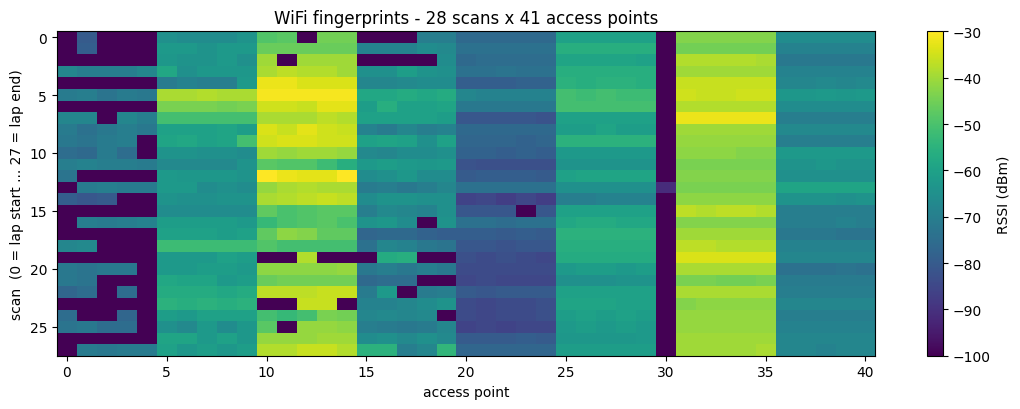

matrix (28, 41) | 11% of cells are 'not heard' (floor -100)


In [4]:
# The whole modality as one image: every scan's fingerprint. Dark = AP not heard (floor -100 dBm).
import matplotlib.pyplot as plt
M, bssids, t_ns = ds.wifi_matrix()            # (28, n_ap); stale-filtered; missing AP -> -100 dBm
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=-100, vmax=-30, interpolation="nearest")
ax.set_xlabel("access point"); ax.set_ylabel("scan  (0 = lap start ... 27 = lap end)")
ax.set_title(f"WiFi fingerprints - {M.shape[0]} scans x {M.shape[1]} access points")
fig.colorbar(im, label="RSSI (dBm)"); plt.tight_layout(); plt.show()
print(f"matrix {M.shape} | {(M==-100).mean()*100:.0f}% of cells are 'not heard' (floor -100)")

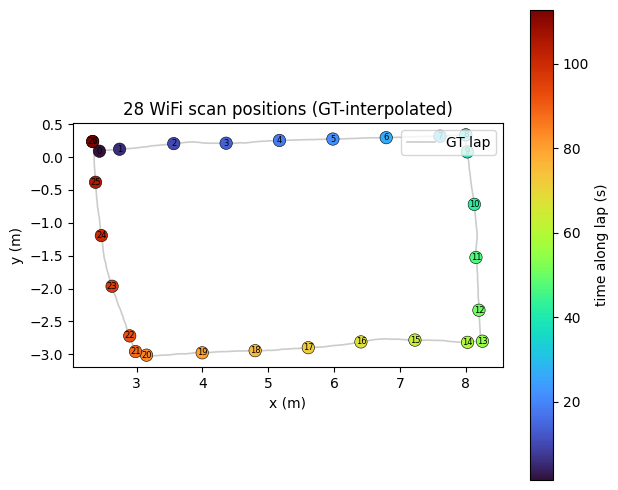

In [5]:
# Where WiFi samples the room: the 28 scan positions on the ground-truth lap.
rel = (t_ns - ds.gt.t_ns.iloc[0]) / 1e9
xs, ys, _ = ds.gt_at(t_ns)                    # GT position interpolated to each scan-end stamp
fig, ax = plt.subplots(figsize=(6.2, 5))
ax.plot(ds.gt.x, ds.gt.y, "-", color="0.8", lw=1.2, label="GT lap", zorder=1)
sc = ax.scatter(xs, ys, c=rel, cmap="turbo", s=80, zorder=3, edgecolor="k", linewidth=0.4)
for i, (x, y) in enumerate(zip(xs, ys)):
    ax.annotate(str(i), (x, y), fontsize=6, ha="center", va="center", zorder=4)
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("28 WiFi scan positions (GT-interpolated)")
fig.colorbar(sc, label="time along lap (s)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()